In [33]:
# OASIS Infobyte - Data Science Internship
# Task 3: Car Price Prediction with Machine Learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the used-car dataset directly
url = "https://raw.githubusercontent.com/HarshKapadia2/car-details/main/data/car_details_v3.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [34]:
# ============================================================
# SECTION 2: DATA CLEANING AND FEATURE ENGINEERING
# ============================================================

# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna().copy()

# Create car age using the latest year in the dataset
current_year = df["year"].max()
df["car_age"] = current_year - df["year"]

print("\nDataset shape after cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

display(df.head())

Missing values before cleaning:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        205
torque           209
seats            208
dtype: int64

Dataset shape after cleaning: (6717, 14)

Missing values after cleaning:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
car_age          0
dtype: int64


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,car_age
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,6
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,6
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,14
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,10
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,13


In [35]:
# Create car brand from the car name
df["brand"] = df["name"].str.split().str[0].str.strip()

print("Brand feature created successfully.")

Brand feature created successfully.


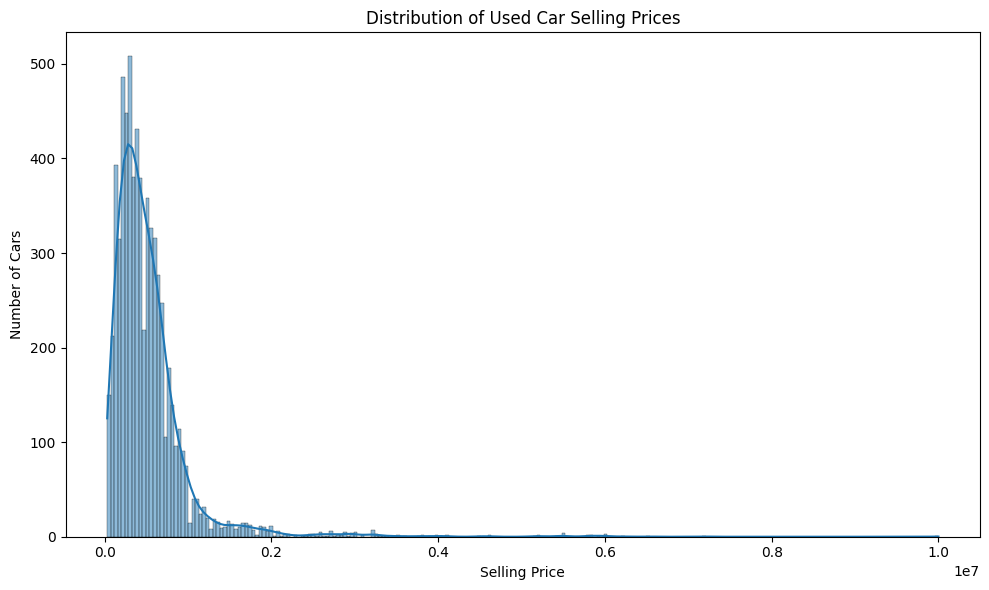

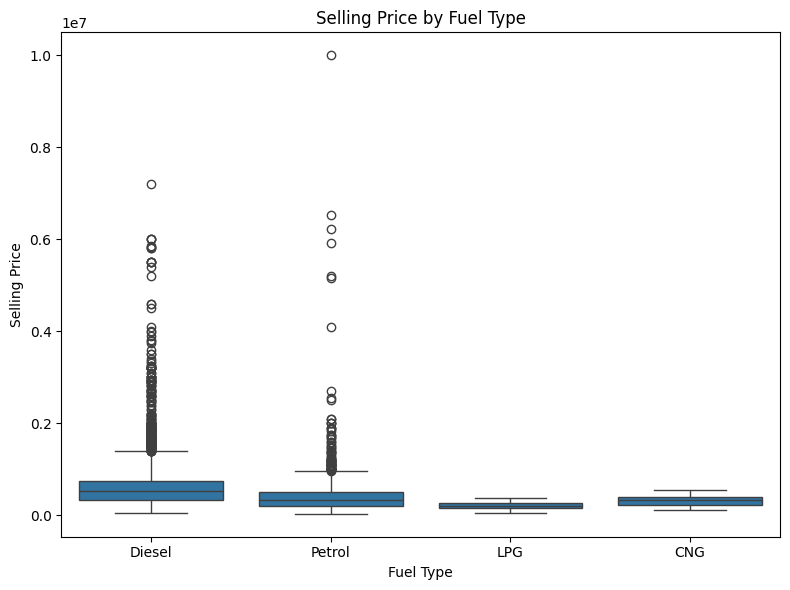

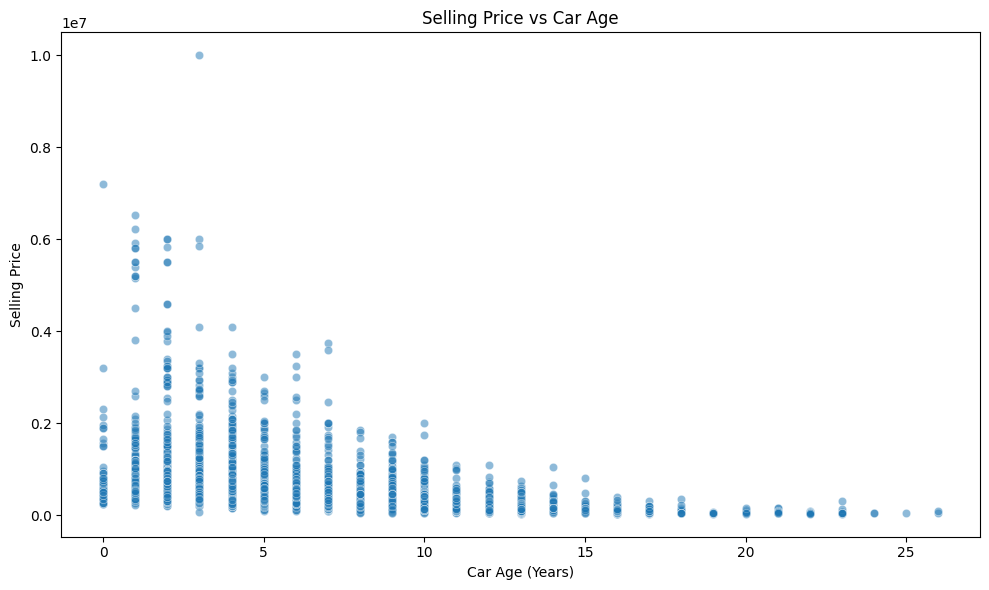

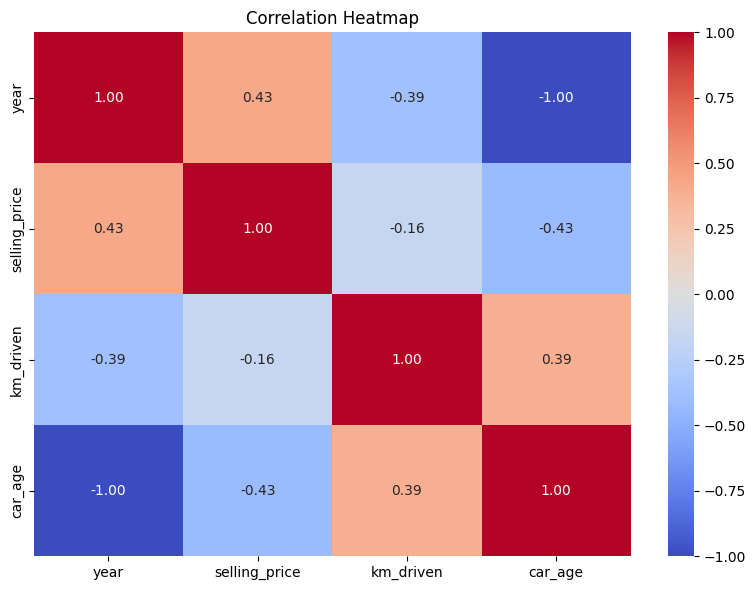

In [36]:
# ============================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS
# ============================================================

# Price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["selling_price"], kde=True)
plt.title("Distribution of Used Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

# Selling price vs fuel type
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="fuel", y="selling_price")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

# Selling price vs car age
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="car_age", y="selling_price", alpha=0.5)
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

# Numerical correlation heatmap
numeric_columns = [
    "year",
    "selling_price",
    "km_driven",
    "car_age"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# SECTION 4: DATA PREPARATION FOR MACHINE LEARNING
# ============================================================

from sklearn.model_selection import train_test_split

# Select features and target
features = [
    "year",
    "km_driven",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "car_age",
    "brand"
]

X = df[features]
y = df["selling_price"]

# Convert categorical columns into numerical dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Number of features after encoding:", X.shape[1])

Training data: (5373, 43)
Testing data: (1344, 43)
Number of features after encoding: 43


In [38]:
# ============================================================
# SECTION 5: MACHINE LEARNING MODELS
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Random Forest Regression
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
random_forest_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print("Random Forest Regression model trained successfully.")

Linear Regression model trained successfully.
Random Forest Regression model trained successfully.


In [39]:
# ============================================================
# SECTION 6: MODEL EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)

# Function to calculate evaluation metrics
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return mae, rmse, r2

# Evaluate Linear Regression
linear_metrics = evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_linear
)

# Evaluate Random Forest
rf_metrics = evaluate_model(
    "Random Forest Regression",
    y_test,
    y_pred_rf
)

# Model comparison table
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regression"],
    "MAE": [linear_metrics[0], rf_metrics[0]],
    "RMSE": [linear_metrics[1], rf_metrics[1]],
    "R²": [linear_metrics[2], rf_metrics[2]]
})

print("\nModel Comparison:")
display(comparison)


Linear Regression
----------------------------------------
MAE  : 159313.25
RMSE : 272773.80
R²   : 0.6609

Random Forest Regression
----------------------------------------
MAE  : 135069.95
RMSE : 235441.31
R²   : 0.7474

Model Comparison:


,Model,MAE,RMSE,R²
0,Linear Regression,159313.246838,272773.795811,0.660916
1,Random Forest Regression,135069.952659,235441.310957,0.747380


Feature Importance:


,Feature,Importance
8,transmission_Manual,2.282661e-01
1,km_driven,1.343318e-01
0,year,1.021090e-01
2,car_age,9.764989e-02
3,fuel_Diesel,6.496851e-02
42,brand_Volvo,5.195807e-02
15,brand_BMW,4.670255e-02
5,fuel_Petrol,4.165328e-02
11,owner_Test Drive Car,3.560266e-02
40,brand_Toyota,3.539627e-02


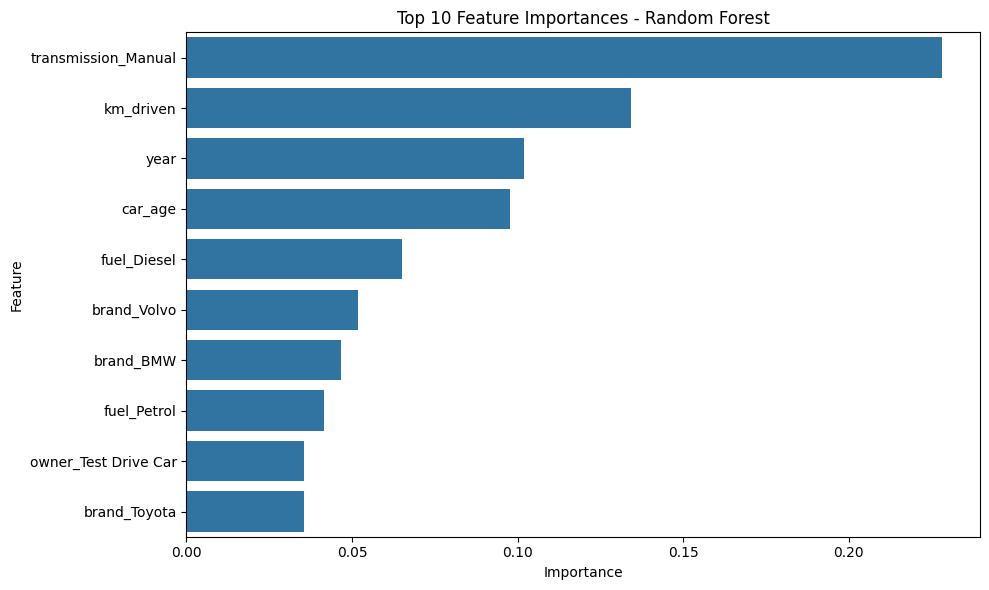

In [40]:
# ============================================================
# SECTION 7: FEATURE IMPORTANCE OF RANDOM FOREST
# ============================================================

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# SECTION 8: BEST MODEL SELECTION
# ============================================================

# Random Forest is generally preferred when it achieves
# lower MAE/RMSE and higher R² than Linear Regression.

if (
    rf_metrics[0] < linear_metrics[0]
    and rf_metrics[1] < linear_metrics[1]
    and rf_metrics[2] > linear_metrics[2]
):
    best_model = "Random Forest Regression"
else:
    best_model = "Linear Regression"

print("Best-performing model:", best_model)

print("\nReason:")
if best_model == "Random Forest Regression":
    print(
        "Random Forest achieved lower MAE and RMSE and higher "
        "R² than Linear Regression on the test dataset."
    )
else:
    print(
        "Linear Regression achieved better evaluation metrics "
        "than Random Forest on the test dataset."
    )

Best-performing model: Random Forest Regression

Reason:
Random Forest achieved lower MAE and RMSE and higher R² than Linear Regression on the test dataset.


In [42]:
# ============================================================
# SECTION 9: FINAL OBSERVATIONS
# ============================================================

# Get the most important feature
top_feature = feature_importance.iloc[0]["Feature"]

print("KEY OBSERVATIONS")
print("-" * 50)

print(f"1. The dataset contains {df.shape[0]} car records after cleaning.")

print(
    f"2. The best-performing model for predicting selling price is "
    f"{best_model}."
)

print(
    f"3. The most important feature according to the Random Forest "
    f"model is '{top_feature}'."
)

print(
    "4. Car age, mileage, fuel type, transmission, ownership and "
    "other vehicle characteristics influence used-car prices."
)

print(
    "5. The model evaluation was performed using MAE, RMSE and R²."
)

KEY OBSERVATIONS
--------------------------------------------------
1. The dataset contains 6717 car records after cleaning.
2. The best-performing model for predicting selling price is Random Forest Regression.
3. The most important feature according to the Random Forest model is 'transmission_Manual'.
4. Car age, mileage, fuel type, transmission, ownership and other vehicle characteristics influence used-car prices.
5. The model evaluation was performed using MAE, RMSE and R².


In [43]:
# Create car brand from the car name
df["brand"] = df["name"].str.split().str[0].str.strip()

print("Sample brand values:")
display(df[["name", "brand"]].head())

Sample brand values:


,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti


In [44]:
print(df.columns.tolist())

['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'car_age', 'brand']


## Conclusion

The Car Price Prediction project successfully predicted used-car selling prices using machine learning.

The dataset was cleaned and important features such as car age and brand were engineered. Exploratory data analysis was performed to understand price patterns and relationships between different features.

Linear Regression and Random Forest Regression were trained and evaluated using MAE, RMSE, and R². Random Forest Regression performed better on the test dataset.

Overall, the project demonstrates how machine learning can be used to predict used-car prices based on vehicle characteristics.